# Operational Metrics — Velox Foods

In the previous notebook, we asked: **"Is the model smart?"**

We measured MAE and Recall and found out how closely Ollama and Groq matched human judgment.

But intelligence is only half the battle. Marcus also needs to know: **"Is the model viable?"**

A model that is 1% smarter but costs 100x more, or ties up your laptop for a week, is not a
practical solution for 514 restaurants.

In this notebook we'll analyse the **metadata** we collected during our pipeline runs to answer:
- How fast is each model?
- How reliable is each model (error rate)?
- What would it actually cost to process Velox Foods' review backlog?
- Is the cloud option worth paying for?


---
## 1.&nbsp; Set-up 🛠️

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")


---
## 2.&nbsp; Understanding the Metrics with Simulated Data

Before loading our real data, let's build intuition with toy numbers — the same approach
as the course lesson, just adapted to our five-aspect restaurant context.


In [2]:
# Simulated metadata for 20 reviews
ollama_sim = pd.DataFrame({
    'review_id': range(1, 21),
    'total_duration_ns': [
        5500000000, 6200000000, 5800000000, 12000000000, 5900000000,
        6100000000, 5700000000, None,        6300000000, 5600000000,
        6000000000, 6400000000, 5900000000, 6200000000, 15000000000,
        5800000000, 6100000000, None,        5700000000, 6000000000
    ],
    'input_token_count':  [250] * 20,
    'output_token_count': [120] * 20,
})

groq_sim = pd.DataFrame({
    'review_id': range(1, 21),
    'total_time':   [0.25, 0.31, 0.28, 0.29, 0.22,
                     0.26, 0.30, 0.24, 0.28, 0.27,
                     0.29, 0.25, 0.28, 0.32, 0.26,
                     0.27, 0.29, 0.25, 0.28, 0.30],
    'input_tokens':  [260] * 20,
    'output_tokens': [115] * 20,
})


Ollama reports time in **nanoseconds** (1 billionth of a second). Groq reports in **seconds**.
We must standardise to seconds before any comparison.


In [3]:
ollama_sim['duration_sec'] = ollama_sim['total_duration_ns'] / 1e9
groq_sim['duration_sec']   = groq_sim['total_time']

print("Ollama sample:")
print(ollama_sim[['review_id', 'total_duration_ns', 'duration_sec']].head())
print()
print("Groq sample:")
print(groq_sim[['review_id', 'total_time', 'duration_sec']].head())


Ollama sample:
   review_id  total_duration_ns  duration_sec
0          1       5.500000e+09           5.5
1          2       6.200000e+09           6.2
2          3       5.800000e+09           5.8
3          4       1.200000e+10          12.0
4          5       5.900000e+09           5.9

Groq sample:
   review_id  total_time  duration_sec
0          1        0.25          0.25
1          2        0.31          0.31
2          3        0.28          0.28
3          4        0.29          0.29
4          5        0.22          0.22


### 2.1 Speed boxplot — simulated data

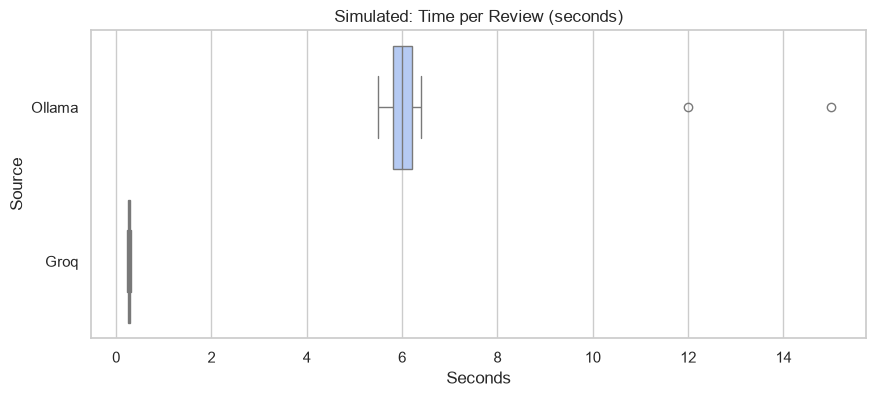

In [4]:
plt.figure(figsize=(10, 4))

plot_sim = pd.DataFrame({
    'Duration': pd.concat([ollama_sim['duration_sec'],
                           groq_sim['duration_sec']], ignore_index=True),
    'Source': ['Ollama'] * len(ollama_sim) + ['Groq'] * len(groq_sim),
})

sns.boxplot(x='Duration', y='Source', hue='Source',
            data=plot_sim, palette='coolwarm', legend=False)

plt.title('Simulated: Time per Review (seconds)')
plt.xlabel('Seconds')
plt.show()


**How to read this boxplot:**
- **The box** = middle 50% of your data; narrower means more consistent.
- **The centre line** = median processing time.
- **Dots beyond the whiskers** = outliers — reviews that took much longer than usual.
  Notice the local model has occasional spikes (12s, 15s). These could be caused by the
  model "thinking harder" on a complex review, or your laptop doing something else in the
  background. Outliers make scheduling unpredictable.


### 2.2 The backlog calculation — simulated

In [5]:
backlog_size = 50_000

avg_ollama_sim = ollama_sim['duration_sec'].mean()
avg_groq_sim   = groq_sim['duration_sec'].mean()

ollama_hours = (avg_ollama_sim * backlog_size) / 3600
groq_hours   = (avg_groq_sim   * backlog_size) / 3600

print(f"--- Simulated: Time to Process {backlog_size:,} Reviews ---")
print(f"Local (Ollama): {ollama_hours:.1f} hours  ({ollama_hours/24:.1f} days)")
print(f"Cloud (Groq):   {groq_hours:.1f} hours  ({groq_hours/24:.1f} days)")


--- Simulated: Time to Process 50,000 Reviews ---
Local (Ollama): 94.3 hours  (3.9 days)
Cloud (Groq):   3.8 hours  (0.2 days)


**The "Laptop Problem":** if the Ollama figure is dozens of hours, remember that means
your laptop is unusable for that entire period. Close the lid — it stops. Join a Zoom call —
it might crash. The cloud option runs on Groq's servers and frees you up entirely.


---
## 3.&nbsp; Real Velox Foods Data

Now let's do the same analysis on the actual metadata from our two pipeline runs.


In [6]:
df_ollama = pd.read_csv('../data/ollama_metadata.csv', index_col='review_id')
df_groq   = pd.read_csv('../data/groq_metadata.csv',   index_col='review_id')

print("Ollama metadata shape:", df_ollama.shape)
print("Ollama columns:", df_ollama.columns.tolist())
print()
print("Groq metadata shape:", df_groq.shape)
print("Groq columns:", df_groq.columns.tolist())


Ollama metadata shape: (200, 8)
Ollama columns: ['model_name', 'created_at', 'total_duration_ns', 'load_duration_ns', 'prompt_eval_duration_ns', 'generation_duration_ns', 'input_token_count', 'output_token_count']

Groq metadata shape: (50, 6)
Groq columns: ['model_name', 'created_at_unix', 'input_tokens', 'output_tokens', 'total_tokens', 'total_time']


In [7]:
df_ollama.head()

,model_name,created_at,total_duration_ns,load_duration_ns,prompt_eval_duration_ns,generation_duration_ns,input_token_count,output_token_count
review_id,,,,,,,,
5dIleZpTxKwjRqBercHV1w,llama3.2,2026-06-25T22:46:30.213198Z,3073474416,115305125,171235000,2784785000,942,120
LETLlxzUzv4eHkD84jea-Q,llama3.2,2026-06-25T22:46:33.310647Z,3093044833,96911208,170902000,2823207000,963,122
9sXneDy_Oyd-n-bCUz6TLg,llama3.2,2026-06-25T22:46:36.583233Z,3268293000,96245542,254421000,2915008000,969,126
0tBSNwWA3eMtbBC2PgzQtQ,llama3.2,2026-06-25T22:46:40.146397Z,3558043625,103400500,324086000,3127705000,1005,135
YMiytO01Ocd6rT-0XWfacQ,llama3.2,2026-06-25T22:46:43.508934Z,3358600583,101996750,406681000,2847145000,1041,123


In [8]:
df_groq.head()

,model_name,created_at_unix,input_tokens,output_tokens,total_tokens,total_time
review_id,,,,,,
5dIleZpTxKwjRqBercHV1w,llama-3.3-70b-versatile,1782801131,968,116,1084,0.354655
LETLlxzUzv4eHkD84jea-Q,llama-3.3-70b-versatile,1782801131,989,118,1107,0.259582
9sXneDy_Oyd-n-bCUz6TLg,llama-3.3-70b-versatile,1782801132,995,113,1108,0.403260
0tBSNwWA3eMtbBC2PgzQtQ,llama-3.3-70b-versatile,1782801133,1031,145,1176,0.625022
YMiytO01Ocd6rT-0XWfacQ,llama-3.3-70b-versatile,1782801134,1067,133,1200,0.370744


### 3.1 Standardise time to seconds

Ollama stores duration in nanoseconds (`total_duration_ns`). Groq stores it in seconds
(`total_time`). We convert both to a common `duration_sec` column.


In [9]:
# Ollama: nanoseconds -> seconds
df_ollama['duration_sec'] = df_ollama['total_duration_ns'] / 1e9

# Groq: already in seconds
df_groq['duration_sec'] = df_groq['total_time']

print("Ollama duration range (seconds):",
      df_ollama['duration_sec'].min(), "-", df_ollama['duration_sec'].max())
print("Groq duration range (seconds):  ",
      df_groq['duration_sec'].min(),   "-", df_groq['duration_sec'].max())


Ollama duration range (seconds): 2.900895 - 9.221270709
Groq duration range (seconds):   0.178140159 - 0.625021723


---
## 4.&nbsp; Reliability — Error Rate

A failed review (all retries exhausted) shows up in our metadata as a row where
`duration_sec` is NaN (no response was ever recorded). Let's count those.

A model with a high error rate means **human time** spent re-running jobs and investigating
failures — that's a real operational cost even if the model itself is free.


In [10]:
def error_rate(df, duration_col='duration_sec'):
    total  = len(df)
    failed = df[duration_col].isna().sum()
    rate   = failed / total * 100
    return total, failed, rate

o_total, o_failed, o_rate = error_rate(df_ollama)
g_total, g_failed, g_rate = error_rate(df_groq)

print(f"{'Model':<10} {'Total':>6} {'Failed':>8} {'Error Rate':>12}")
print("-" * 40)
print(f"{'Ollama':<10} {o_total:>6} {o_failed:>8} {o_rate:>11.1f}%")
print(f"{'Groq':<10}   {g_total:>6} {g_failed:>8} {g_rate:>11.1f}%")


Model       Total   Failed   Error Rate
----------------------------------------
Ollama        200        0         0.0%
Groq             50        0         0.0%


---
## 5.&nbsp; Speed & Throughput ⏱️

Speed tells us how many reviews we can process per hour — and therefore how viable each
pipeline is at Velox Foods' real weekly volume.


In [11]:
print("--- Speed Summary (seconds per review) ---")
print()
print("Ollama:")
print(df_ollama['duration_sec'].describe().round(2))
print()
print("Groq:")
print(df_groq['duration_sec'].describe().round(2))


--- Speed Summary (seconds per review) ---

Ollama:
count    200.00
mean       4.77
std        1.02
min        2.90
25%        4.19
50%        4.54
75%        5.29
max        9.22
Name: duration_sec, dtype: float64

Groq:
count    50.00
mean      0.33
std       0.08
min       0.18
25%       0.27
50%       0.31
75%       0.37
max       0.63
Name: duration_sec, dtype: float64


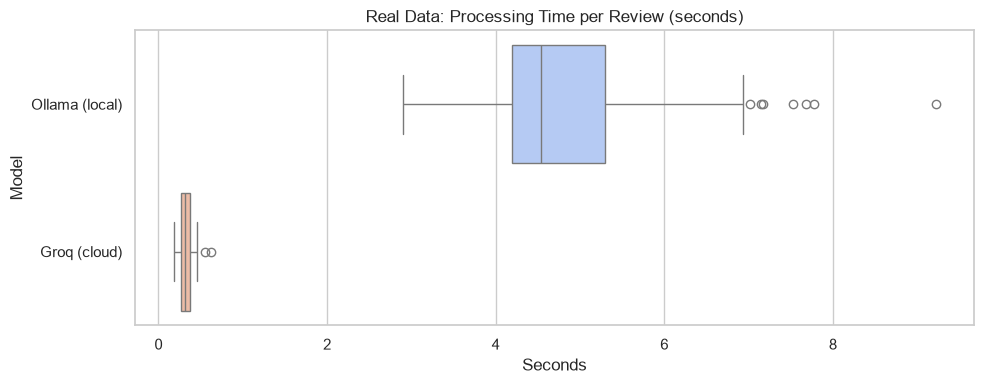

Saved to ../data/speed_boxplot.png


In [12]:
plt.figure(figsize=(10, 4))

plot_data = pd.DataFrame({
    'Duration': pd.concat([df_ollama['duration_sec'],
                           df_groq['duration_sec']], ignore_index=True),
    'Model': (['Ollama (local)'] * len(df_ollama) +
              ['Groq (cloud)']   * len(df_groq)),
})

sns.boxplot(x='Duration', y='Model', hue='Model',
            data=plot_data, palette='coolwarm', legend=False)

plt.title('Real Data: Processing Time per Review (seconds)')
plt.xlabel('Seconds')
plt.tight_layout()
plt.savefig('../data/speed_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ../data/speed_boxplot.png")


---
## 6.&nbsp; The Backlog Calculation

**Velox Foods context:**
- 514 restaurants
- Let's estimate ~20 new reviews per restaurant per week = **10,280 reviews/week**
- Plus an existing backlog of 50,000 unread reviews

How long would each pipeline take?


In [13]:
BACKLOG        = 50_000
WEEKLY_REVIEWS = 514 * 20   # 10,280

avg_ollama = df_ollama['duration_sec'].mean()
avg_groq   = df_groq['duration_sec'].mean()

print(f"Average time per review:")
print(f"  Ollama: {avg_ollama:.2f}s")
print(f"  Groq:   {avg_groq:.2f}s")
print()

for label, avg in [('Ollama (local)', avg_ollama), ('Groq (cloud)', avg_groq)]:
    backlog_hours  = (avg * BACKLOG) / 3600
    weekly_minutes = (avg * WEEKLY_REVIEWS) / 60
    print(f"--- {label} ---")
    print(f"  Backlog ({BACKLOG:,} reviews):        {backlog_hours:.1f} hours  ({backlog_hours/24:.1f} days)")
    print(f"  Weekly run ({WEEKLY_REVIEWS:,} reviews): {weekly_minutes:.0f} minutes")
    print()


Average time per review:
  Ollama: 4.77s
  Groq:   0.33s

--- Ollama (local) ---
  Backlog (50,000 reviews):        66.3 hours  (2.8 days)
  Weekly run (10,280 reviews): 818 minutes

--- Groq (cloud) ---
  Backlog (50,000 reviews):        4.6 hours  (0.2 days)
  Weekly run (10,280 reviews): 56 minutes



---
## 7.&nbsp; The Economics (Token Costs) 💰

Ollama is free (minus electricity). Groq costs money per token. Let's calculate the real bill
using the token counts from our metadata — this is the number Marcus actually asked for.

We compare three providers for the same model class:
- **Groq** — llama-3.3-70b-versatile
- **OpenAI** — gpt-4o-mini (comparable capability tier)
- **Google** — gemini-1.5-flash (comparable capability tier)

*(Check current prices at each provider's pricing page — rates change frequently.)*


In [14]:
# Current pricing per 1M tokens (verify at provider pricing pages before use)
PROVIDERS = {
    'Groq (llama-3.3-70b)': {'input': 0.59,  'output': 0.79},
    'OpenAI (gpt-4o-mini)': {'input': 0.15,  'output': 0.60},
    'Google (gemini-flash)': {'input': 0.075, 'output': 0.30},
}

avg_input_tokens  = df_groq['input_tokens'].mean()
avg_output_tokens = df_groq['output_tokens'].mean()

print(f"Average tokens per review (from our Groq run):")
print(f"  Input:  {avg_input_tokens:.0f} tokens")
print(f"  Output: {avg_output_tokens:.0f} tokens")
print()

for scenario_name, n_reviews in [
    (f'Our pilot (50 reviews)',               50),
    (f'Full dataset (200 reviews)',            200),
    (f'Weekly volume ({514*20:,} reviews)',    514 * 20),
    (f'Monthly volume ({514*80:,} reviews)',   514 * 80),
]:
    total_input_M  = (avg_input_tokens  * n_reviews) / 1_000_000
    total_output_M = (avg_output_tokens * n_reviews) / 1_000_000

    print(f"=== {scenario_name} ===")
    for provider, prices in PROVIDERS.items():
        cost = total_input_M * prices['input'] + total_output_M * prices['output']
        print(f"  {provider:<30} ${cost:.4f}")
    print()


Average tokens per review (from our Groq run):
  Input:  1031 tokens
  Output: 108 tokens

=== Our pilot (50 reviews) ===
  Groq (llama-3.3-70b)           $0.0347
  OpenAI (gpt-4o-mini)           $0.0110
  Google (gemini-flash)          $0.0055

=== Full dataset (200 reviews) ===
  Groq (llama-3.3-70b)           $0.1388
  OpenAI (gpt-4o-mini)           $0.0439
  Google (gemini-flash)          $0.0220

=== Weekly volume (10,280 reviews) ===
  Groq (llama-3.3-70b)           $7.1352
  OpenAI (gpt-4o-mini)           $2.2585
  Google (gemini-flash)          $1.1293

=== Monthly volume (41,120 reviews) ===
  Groq (llama-3.3-70b)           $28.5409
  OpenAI (gpt-4o-mini)           $9.0340
  Google (gemini-flash)          $4.5170



**Take a moment to look at those numbers.** AI text analysis is often surprisingly cheap.
If the total monthly cost across all three providers is under $10-20, does it make sense
to tie up a laptop for days — or risk a lower-quality local model — to save that money?

That's the core trade-off Marcus needs to decide on.


### 7.1 Can we reduce the cost by shortening the system prompt?

Most of the input tokens are our long system prompt (sent with every single review). If we
can shorten it significantly, we reduce input costs for every review processed.


In [15]:
# Estimate: what if we cut input tokens by 30%?
reduction = 0.30
reduced_input = avg_input_tokens * (1 - reduction)

print(f"Current avg input tokens:  {avg_input_tokens:.0f}")
print(f"After 30% reduction:       {reduced_input:.0f}")
print()

monthly_reviews = 514 * 80
for provider, prices in PROVIDERS.items():
    cost_current = ((avg_input_tokens  * monthly_reviews / 1_000_000) * prices['input'] +
                    (avg_output_tokens * monthly_reviews / 1_000_000) * prices['output'])
    cost_reduced = ((reduced_input     * monthly_reviews / 1_000_000) * prices['input'] +
                    (avg_output_tokens * monthly_reviews / 1_000_000) * prices['output'])
    saving = cost_current - cost_reduced
    print(f"{provider:<30}  current: ${cost_current:.4f}  reduced: ${cost_reduced:.4f}  saving: ${saving:.4f}")


Current avg input tokens:  1031
After 30% reduction:       722

Groq (llama-3.3-70b)            current: $28.5409  reduced: $21.0342  saving: $7.5066
OpenAI (gpt-4o-mini)            current: $9.0340  reduced: $7.1256  saving: $1.9085
Google (gemini-flash)           current: $4.5170  reduced: $3.5628  saving: $0.9542


---
## 8.&nbsp; The Verdict for Marcus

Run the cell below for an auto-generated operational summary you can paste into the report.


In [16]:
import json

with open('../data/ollama_summary.json') as f:
    ollama_sum = json.load(f)
with open('../data/groq_summary.json') as f:
    groq_sum = json.load(f)

weekly = 514 * 20
monthly = 514 * 80
avg_in  = df_groq['input_tokens'].mean()
avg_out = df_groq['output_tokens'].mean()

groq_prices = PROVIDERS['Groq (llama-3.3-70b)']
weekly_cost  = (avg_in * weekly  / 1_000_000) * groq_prices['input']  +                (avg_out * weekly  / 1_000_000) * groq_prices['output']
monthly_cost = (avg_in * monthly / 1_000_000) * groq_prices['input']  +                (avg_out * monthly / 1_000_000) * groq_prices['output']

backlog_ollama_days = (df_ollama['duration_sec'].mean() * 50_000) / 3600 / 24
backlog_groq_hours  = (df_groq['duration_sec'].mean()   * 50_000) / 3600

print("=" * 60)
print("OPERATIONAL SUMMARY - VELOX FOODS ABSA PILOT")
print("=" * 60)
print()
print("RELIABILITY (error rate):")
print(f"  Ollama: {o_rate:.1f}% failed  ({o_failed} of {o_total} reviews)")
print(f"  Groq:   {g_rate:.1f}% failed  ({g_failed} of {g_total} reviews)")
print()
print("SPEED (average per review):")
print(f"  Ollama: {df_ollama['duration_sec'].mean():.2f}s")
print(f"  Groq:   {df_groq['duration_sec'].mean():.2f}s")
print()
print("BACKLOG (50,000 unread reviews):")
print(f"  Ollama: {backlog_ollama_days:.1f} days  (laptop tied up)")
print(f"  Groq:   {backlog_groq_hours:.1f} hours (runs on Groq servers)")
print()
print(f"WEEKLY COST (Groq, {weekly:,} reviews/week):")
print(f"  ${weekly_cost:.4f}")
print()
print(f"MONTHLY COST (Groq, {monthly:,} reviews/month):")
print(f"  ${monthly_cost:.4f}")
print()
print("BOTTOM LINE:")
if monthly_cost < 10:
    verdict = "extremely low"
elif monthly_cost < 50:
    verdict = "low"
else:
    verdict = "moderate"
print(f"  Monthly cloud cost is {verdict}. Compare this against the cost")
print(f"  of a analyst's time spent babysitting a local pipeline for")
print(f"  {backlog_ollama_days:.0f} days, or the risk of lower accuracy from the local model.")
print("=" * 60)


OPERATIONAL SUMMARY - VELOX FOODS ABSA PILOT

RELIABILITY (error rate):
  Ollama: 0.0% failed  (0 of 200 reviews)
  Groq:   0.0% failed  (0 of 50 reviews)

SPEED (average per review):
  Ollama: 4.77s
  Groq:   0.33s

BACKLOG (50,000 unread reviews):
  Ollama: 2.8 days  (laptop tied up)
  Groq:   4.6 hours (runs on Groq servers)

WEEKLY COST (Groq, 10,280 reviews/week):
  $7.1352

MONTHLY COST (Groq, 41,120 reviews/month):
  $28.5409

BOTTOM LINE:
  Monthly cloud cost is low. Compare this against the cost
  of a analyst's time spent babysitting a local pipeline for
  3 days, or the risk of lower accuracy from the local model.


---
## Key Takeaways 🧠

* **Reliability is a cost.** A free model that fails 2% of reviews means human time spent
  identifying and re-running those jobs. Factor that into "total cost of ownership."
* **Time is money.** Calculate the "Laptop Cost." If your machine is unusable for 3 days,
  that blocks other work — even if the model itself is free.
* **Token economics.** AI is often cheaper than you'd expect. Always run the numbers before
  assuming cloud is too expensive. The monthly bill for Velox Foods may be less than a
  single hour of analyst time.
* **The trade-off.** There is no perfect model. You trade cost for privacy, speed for
  accuracy, convenience for control. Your job as a data analyst is to quantify each side
  of that trade-off so Marcus can make an informed decision — not to make the decision for him.
